In [4]:
import numpy as np
import pyref.fitting as fit
from refnx.analysis import Parameter, Parameters

from utils import read_ooc, read_xrr
from utils.profile_slab import OrientationProfile
from utils.slab_builders import sio2, substrate, surface, vacuum


/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [5]:
oocs = read_ooc("dft.csv", material="znpc")
data = read_xrr("reflectivity_data", material="znpc")

In [6]:
import pickle

from utils import models_root

with open(models_root / "xrr/dft/dft_en_offset_new2.pkl", "rb") as f:
    dft_constrained = pickle.load(f)

In [7]:
energy_offset = dft_constrained.objectives[0].model.energy_offset.value
surface_density = dft_constrained.objectives[0].model.structure.components[1].sld.density.value
surface_roughness = dft_constrained.objectives[0].model.structure.components[1].rough.value
surface_thickness = dft_constrained.objectives[0].model.structure.components[1].thick.value
# bulk
bulk_density = dft_constrained.objectives[0].model.structure.components[2].sld.density.value

In [8]:
surface_density, bulk_density

(np.float64(1.8), np.float64(1.6385167795334732))

In [9]:
def model(
    energy: float,
    total_thick: float = 191.5,
    surface_roughness: float = 12.301979543127507,
    density: float = 1.6153,
    characteristic_thickness: float = 12.2,
    max_angle: float = 1.2,
    initial_angle: float = 0,
    num_slabs: int = 20,
):
    energy = float(energy)
    return (
        vacuum(energy)  # type: ignore
        | surface(energy, oocs, thick=surface_thickness, rough=surface_roughness, density=surface_density)
        | OrientationProfile(
            oocs,
            energy=energy,
            total_thick=total_thick,
            surface_roughness=surface_roughness,
            density=bulk_density,
            characteristic_thickness=characteristic_thickness,
            max_angle=max_angle,
            initial_angle=initial_angle,
            name=f"ZnPc_{energy:.1f}",
            # num_slabs=num_slabs,
        )
        | sio2(energy)
        | substrate(energy)
    )

In [10]:
on_grid = [283.7]

models = {str(e): model(e) for e in data if float(e) in on_grid}
template = models["283.7"]

# Surface Layer
template.components[1].thick.setp(vary=True, bounds=(0, 80))
template.components[1].rough.setp(vary=True, bounds=(0, 25))
template.components[1].sld.density.setp(vary=True, bounds=(1.0, 2))
template.components[1].sld.rotation.setp(vary=True, bounds=(0, np.pi/2))

# ZnPc Layer
template.components[2].total_thick.setp(vary=True, bounds=(160, 210))
template.components[2].surface_roughness.setp(vary=True, bounds=(0, 13))
template.components[2].density.setp(value=1.6153, vary=True, bounds=(1.5, 2))
template.components[2].characteristic_thickness.setp(vary=True, bounds=(0, 100))
template.components[2].max_angle.setp(vary=True, bounds=(np.pi / 4, np.pi/2))
template.components[2].initial_angle.setp(vary=True, bounds=(0, np.pi / 2))
# template.components[2].num_slabs.setp(vary=True, bounds=(10, 30))

# SiO2 Layer
template.components[3].thick.setp(vary=False, bounds=(0, 25))
template.components[3].rough.setp(vary=False, bounds=(0, 25))
template.components[3].sld.density.setp(vary=False)


def filt_struct(x: str) -> bool:
    if "get_" in x.lower() or "get" in x.lower():
        return False
    if "slab" in x.lower():
        return False
    return (
        "thick" in x.lower()
        or "thickness" in x.lower()
        or "rough" in x.lower()
        or "roughness" in x.lower()
    )


def filt_sld(x: str) -> bool:
    if "get_" in x.lower() or "get" in x.lower():
        return False
    return (
        "rot" in x.lower()
        or "rotation" in x.lower()
        or "angle" in x.lower()
        or "density" in x.lower()
        or "rho" in x.lower()
    )


def _link_params(slab, ref):
    # Handle structure parameters
    struct_params = list(filter(filt_struct, dir(slab)))
    for pname in struct_params:
        p = getattr(slab, pname)
        try:
            p.setp(vary=None, constraint=getattr(ref, pname))
        except Exception:
            print(f"Failed to link {pname}")
            print(slab)
            print(ref)

    sld_params_t0 = list(filter(filt_sld, dir(slab)))
    if len(sld_params_t0) != 0:
        for pname in sld_params_t0:
            p = getattr(slab, pname)
            p.setp(vary=None, constraint=getattr(ref, pname))
    sld_params_t1 = list(filter(filt_sld, dir(slab.sld)))
    if len(sld_params_t1) != 0:
        for pname in sld_params_t1:
            p = getattr(slab.sld, pname)
            p.setp(vary=None, constraint=getattr(ref.sld, pname))


def link_params(slab, ref):
    for _slab, _ref in zip(slab.components, ref.components, strict=True):
        _link_params(_slab, _ref)


for e in on_grid:
    if e == 283.7:
        continue
    link_params(models[str(e)], template)

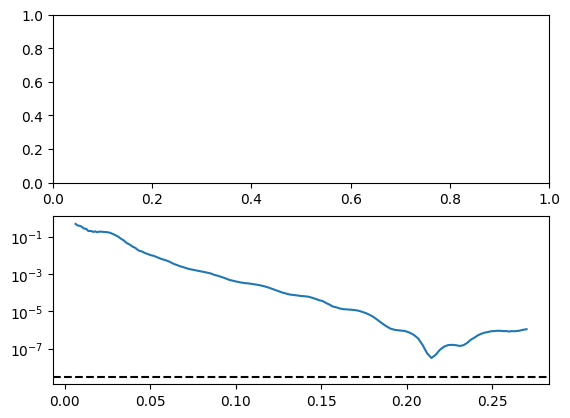

In [20]:
import matplotlib.pyplot as plt

refl: dict[str, fit.ReflectModel] = {
    str(e): fit.ReflectModel(models[str(e)], energy=float(e), pol="sp") for e in on_grid
}
fig, ax = plt.subplots(nrows=2)
for e, ref in refl.items():
    ref.scale_s.setp(vary=True, bounds=(0.5, 2))
    ref.scale_p.setp(vary=True, bounds=(0.5, 2))
    ref.theta_offset_s.setp(vary=True, bounds=(-1, 1))
    ref.theta_offset_p.setp(vary=True, bounds=(-1, 1))
    ref.energy_offset.setp(value = energy_offset, vary=False, bounds=(-.5, .5))
    if e in ["250.0", "283.7"]:
        exp = data[e].p
        min_point = exp.y.argmin()
        min_y = exp.y[min_point]
        min_y_err = exp.y_err[min_point]
        bkg = min_y - min_y_err
        ref.bkg.setp(value=bkg, vary=False)
        i = ["250.0", "283.7"].index(e)
        ax[i].plot(exp.x, exp.y)
        ax[i].set_yscale("log")
        ax[i].axhline(
            ref.bkg.value,
            color="k",
            linestyle="--",
        )


In [21]:
objective: list[fit.AnisotropyObjective] = [
    fit.AnisotropyObjective(
        refl[str(e)], data[str(e)], logp_anisotropy_weight=0.8, transform=fit.Transform("logY")
    )
    for e in on_grid
]
global_objective = fit.GlobalObjective(objective)
print(global_objective.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter:   'scale_s'   , value=1          , bounds=[0.5, 2.0]>
<Parameter:   'scale_p'   , value=1          , bounds=[0.5, 2.0]>
<Parameter:'theta_offset_s', value=0          , bounds=[-1.0, 1.0]>
<Parameter:'theta_offset_p', value=0          , bounds=[-1.0, 1.0]>
<Parameter:'Surface_283.7_thick', value=38.0679  +/- 1.5 , bounds=[0.0, 80.0]>
<Parameter:'Surface_283.7_rough', value=18.2181 +/- 0.846, bounds=[0.0, 25.0]>
<Parameter:'Surface_283.7_density', value=2 +/- 0.0919, bounds=[1.0, 2.0]>
<Parameter:'Surface_283.7_rotation', value=1.28089 +/- 0.0163, bounds=[0.0, 1.5707963267948966]>
<Parameter: 'total_thick' , value=160 +/- 0.73 , bounds=[160.0, 210.0]>
<Parameter:'surface_roughness', value=12.8378 +/- 0.919, bounds=[0.0, 13.0]>
<Parameter:   'density'   , value=1.5165 +/- 3.43e-15, bounds=[1.5, 2.0]>
<Parameter:'characteristic_thickness', value=54.297 +/- 6.42 , bounds=

In [13]:
from time import perf_counter

from utils.helpers.fitting_helper import package_results

fitter = fit.CurveFitter(global_objective)

In [17]:
res = fitter.fit(target = "nlpost", method="differential_evolution", updating="deferred", workers=10)
# res = fitter.fit(method="differential_evolution", updating="deferred", workers=10)

21.267151821120866: : 37it [08:32, 13.85s/it]


In [18]:
print(global_objective.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter:   'scale_s'   , value=1.24242 +/- 0.028, bounds=[0.5, 2.0]>
<Parameter:   'scale_p'   , value=1.21894 +/- 0.0102, bounds=[0.5, 2.0]>
<Parameter:'theta_offset_s', value=-0.0347851 +/- 0.0148, bounds=[-1.0, 1.0]>
<Parameter:'theta_offset_p', value=0.543008 +/- 0.0666, bounds=[-1.0, 1.0]>
<Parameter:'Surface_283.7_thick', value=38.0679  +/- 1.5 , bounds=[0.0, 80.0]>
<Parameter:'Surface_283.7_rough', value=18.2181 +/- 0.846, bounds=[0.0, 25.0]>
<Parameter:'Surface_283.7_density', value=2 +/- 0.0919, bounds=[1.0, 2.0]>
<Parameter:'Surface_283.7_rotation', value=1.28089 +/- 0.0163, bounds=[0.0, 1.5707963267948966]>
<Parameter: 'total_thick' , value=160 +/- 0.73 , bounds=[160.0, 210.0]>
<Parameter:'surface_roughness', value=12.8378 +/- 0.919, bounds=[0.0, 13.0]>
<Parameter:   'density'   , value=1.5165 +/- 3.43e-15, bounds=[1.5, 2.0]>
<Parameter:'characteristic_thickness', 

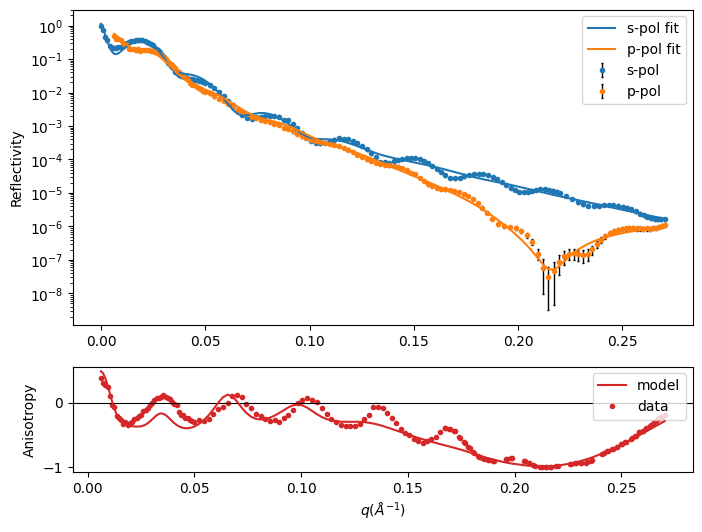

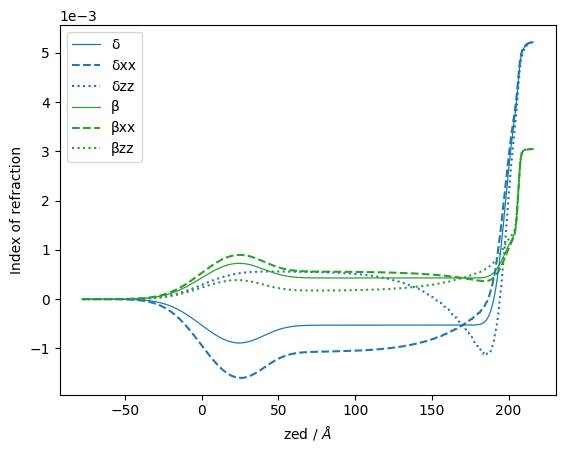

In [19]:
for o in fitter.objective.objectives:
    o.plot()
    plt.show()
    o.model.structure.plot()
    plt.show()

In [9]:
df_output = package_results(fitter = fitter)
df_output

,value
name,
scale_s,0.660+/-0.010
scale_p,0.728+/-0.011
energy_offset,0.5+/-0.7
theta_offset_s,-0.127+/-0.018
theta_offset_p,-0.274+/-0.018
Surface_283.7_thick,0.0+/-0.4
Surface_283.7_rough,5.00+/-0.14
Surface_283.7_density,1.700+/-0.033
Surface_283.7_rotation,0.785+/-0.010


In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import scienceplots

from utils.helpers.plotting_helper import plot_all_results, set_plotting_defaults

set_plotting_defaults()

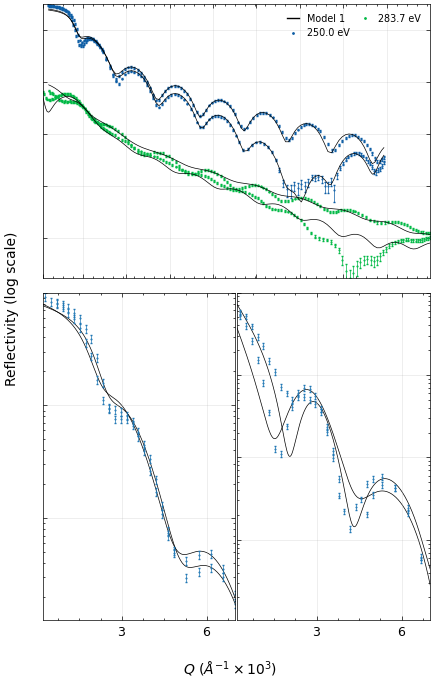

In [12]:
fig = plot_all_results(
    fitter.objective,
    data,
)
fig.set_size_inches(5, 8)